<a href="https://colab.research.google.com/github/Riri27305/Research-Paper/blob/main/ConvNeXt_OvarianTumor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

mount drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp /content/drive/MyDrive/Datasets/ovarian.zip /content/

In [ ]:
!rm -rf /content/ovarian


In [ ]:
!unzip -q /content/ovarian.zip -d /content/

In [ ]:
!ls /content/ovarian


non-tumour  tumour


install libraries

In [ ]:
!pip install -q timm torch torchvision scikit-learn opencv-python


imports

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import timm
import numpy as np
import matplotlib.pyplot as plt
import cv2
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
torch.backends.cudnn.benchmark = True

device

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
!nvidia-smi

Fri Apr  3 10:27:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             11W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

dataset structure

In [ ]:
DATA_DIR = "/content/ovarian"


image transforms

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

load dataset

In [ ]:
dataset = datasets.ImageFolder(DATA_DIR)

print("Classes:", dataset.classes)
print("Total images:", len(dataset))

Classes: ['non-tumour', 'tumour']
Total images: 33110


train/validation split

In [ ]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(
    train_dataset,
    batch_size=64,        # reduced from 96 — safer on RAM
    shuffle=True,
    num_workers=2,        # reduced from 4
    pin_memory=True,
    persistent_workers=False  # set to False — causes issues after reload
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=False  # set to False
)

CBAM Module

In [ ]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = self.fc(self.avg_pool(x).squeeze(-1).squeeze(-1))
        max_ = self.fc(self.max_pool(x).squeeze(-1).squeeze(-1))
        return self.sigmoid(avg + max_).unsqueeze(-1).unsqueeze(-1) * x


class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        max_, _ = x.max(dim=1, keepdim=True)
        return self.sigmoid(self.conv(torch.cat([avg, max_], dim=1))) * x


class CBAM(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.ca = ChannelAttention(channels)
        self.sa = SpatialAttention()

    def forward(self, x):
        return self.sa(self.ca(x))

Multi-Scale ConvNeXt + CBAM Model

In [ ]:
class MultiScaleConvNeXt(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.backbone = timm.create_model(
            "convnext_tiny", pretrained=True, features_only=True
        )

        # CBAM on last 2 stages (384 and 768 channels)
        self.cbam2 = CBAM(384)
        self.cbam3 = CBAM(768)

        # Project stage2 → 768 to match stage3
        self.proj = nn.Conv2d(384, 768, kernel_size=1)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.LayerNorm(768),
            nn.Dropout(0.3),
            nn.Linear(768, num_classes)
        )

        # Learnable adaptive threshold
        self.threshold = nn.Parameter(torch.tensor(0.4))

    def forward(self, x):
        feats = self.backbone(x)

        s2 = self.cbam2(feats[2])   # 384 channels
        s3 = self.cbam3(feats[3])   # 768 channels

        # Upsample s2 to match s3 spatial size, then fuse
        s2_up = F.interpolate(
            self.proj(s2), size=s3.shape[-2:],
            mode='bilinear', align_corners=False
        )
        fused = s2_up + s3

        return self.head(self.pool(fused))


model = MultiScaleConvNeXt(num_classes=2).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Fine-Tuning strategy

In [ ]:
# Freeze everything
for p in model.parameters():
    p.requires_grad = False

# Unfreeze last backbone stage (correct way for FeatureListNet)
last_stage = list(model.backbone.children())[-1]
for p in last_stage.parameters():
    p.requires_grad = True

# Unfreeze CBAM + projection + head
for p in model.cbam2.parameters():
    p.requires_grad = True
for p in model.cbam3.parameters():
    p.requires_grad = True
for p in model.proj.parameters():
    p.requires_grad = True
for p in model.head.parameters():
    p.requires_grad = True

# Threshold is already a learnable parameter
print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Trainable params: 15861702


Focal Loss + Optimizer

In [ ]:
# Simpler weighted CrossEntropy — more stable than Focal for this task
counts = Counter(dataset.targets)
weights = torch.tensor([
    1.0 / counts[0],
    2.0 / counts[1]
], device=device)

# Normalize weights
weights = weights / weights.sum()

criterion = nn.CrossEntropyLoss(
    weight=weights,
    label_smoothing=0.1
)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=0.05
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

TTA + Train/Validate Functions

In [ ]:
def tta_predict(model, images):
    preds = []
    for aug in [
        lambda x: x,
        lambda x: torch.flip(x, dims=[3]),
        lambda x: torch.flip(x, dims=[2]),
        lambda x: torch.rot90(x, k=1, dims=[2, 3])
    ]:
        with torch.no_grad():
            preds.append(torch.softmax(model(aug(images)), dim=1))
    return torch.stack(preds).mean(0)


def train_one_epoch(model, loader):
    model.train()
    running_loss, correct = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        threshold = torch.clamp(model.threshold, 0.3, 0.7).item()
        preds = (torch.softmax(outputs, dim=1)[:, 1] > threshold).long()
        correct += (preds == labels).sum().item()
    return running_loss / len(loader), correct / len(loader.dataset)


def validate(model, loader):
    model.eval()
    running_loss, correct = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            loss = criterion(outputs, labels)  # pass logits, NOT log(probs)
            running_loss += loss.item()
            threshold = torch.clamp(model.threshold, 0.3, 0.7).item()
            preds = (probs[:, 1] > threshold).long()
            correct += (preds == labels).sum().item()
    return running_loss / len(loader), correct / len(loader.dataset)

Training Loop

In [ ]:
import os
import json

CHECKPOINT_PATH = "/content/convnext_checkpoint.pth"
RESULTS_PATH = "/content/drive/MyDrive/training_results.json"
start_epoch = 0
best_val_acc = 0
training_history = []

# ── Load checkpoint if exists ────────────────────────────────
if os.path.exists(CHECKPOINT_PATH):
    print("Loading checkpoint...")
    checkpoint = torch.load(CHECKPOINT_PATH)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    scheduler.load_state_dict(checkpoint["scheduler_state"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_acc = checkpoint["best_val_acc"]
    training_history = checkpoint.get("history", [])
    print(f"Resuming from epoch {start_epoch}")
    print(f"Best val acc so far: {best_val_acc:.4f}")

# ── Load results history from Drive if exists ────────────────
elif os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH, "r") as f:
        training_history = json.load(f)
    print(f"Loaded training history ({len(training_history)} epochs)")

# ── Training loop ────────────────────────────────────────────
EPOCHS = 12
for epoch in range(start_epoch, EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = validate(model, val_loader)
    scheduler.step()
    threshold = torch.clamp(model.threshold, 0.3, 0.7).item()

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print(f"Threshold:  {threshold:.4f}")
    print("-" * 40)

    # Save epoch result to history
    training_history.append({
        "epoch": epoch + 1,
        "train_loss": round(train_loss, 4),
        "train_acc": round(train_acc, 4),
        "val_loss": round(val_loss, 4),
        "val_acc": round(val_acc, 4),
        "threshold": round(threshold, 4)
    })

    # Save checkpoint (resumes from here if interrupted)
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_val_acc": best_val_acc,
        "history": training_history
    }, CHECKPOINT_PATH)

    # Copy checkpoint to Drive every epoch
    !cp /content/convnext_checkpoint.pth /content/drive/MyDrive/

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/content/best_model.pth")
        !cp /content/best_model.pth /content/drive/MyDrive/
        print(f"New best model saved at epoch {epoch+1}!")

    # Save training history to Drive as JSON
    with open(RESULTS_PATH, "w") as f:
        json.dump(training_history, f, indent=2)

print("\nTraining complete!")
print(f"Best Val Accuracy: {best_val_acc:.4f}")

Epoch 1/12
Train Loss: 0.2142 | Train Acc: 0.9850
Val Loss:   0.2119 | Val Acc:   0.9854
Threshold:  0.4000
----------------------------------------
New best model saved at epoch 1!
Epoch 2/12
Train Loss: 0.2039 | Train Acc: 0.9909
Val Loss:   0.2205 | Val Acc:   0.9837
Threshold:  0.4000
----------------------------------------
Epoch 3/12
Train Loss: 0.2008 | Train Acc: 0.9929
Val Loss:   0.2099 | Val Acc:   0.9864
Threshold:  0.4000
----------------------------------------
New best model saved at epoch 3!
Epoch 4/12
Train Loss: 0.1963 | Train Acc: 0.9955
Val Loss:   0.2098 | Val Acc:   0.9869
Threshold:  0.4000
----------------------------------------
New best model saved at epoch 4!
Epoch 5/12
Train Loss: 0.1930 | Train Acc: 0.9973
Val Loss:   0.2121 | Val Acc:   0.9857
Threshold:  0.4000
----------------------------------------
Epoch 6/12
Train Loss: 0.1915 | Train Acc: 0.9983
Val Loss:   0.2087 | Val Acc:   0.9893
Threshold:  0.4000
----------------------------------------
New bes

 epoch  train_loss  train_acc  val_loss  val_acc  threshold
     1      0.2142     0.9850    0.2119   0.9854        0.4
     2      0.2039     0.9909    0.2205   0.9837        0.4
     3      0.2008     0.9929    0.2099   0.9864        0.4
     4      0.1963     0.9955    0.2098   0.9869        0.4
     5      0.1930     0.9973    0.2121   0.9857        0.4
     6      0.1915     0.9983    0.2087   0.9893        0.4
     7      0.1907     0.9988    0.2082   0.9887        0.4
     8      0.1897     0.9994    0.2082   0.9893        0.4
     9      0.1892     0.9997    0.2073   0.9896        0.4
    10      0.1890     0.9997    0.2075   0.9897        0.4
    11      0.1890     0.9997    0.2075   0.9897        0.4
    12      0.1889     0.9998    0.2078   0.9893        0.4


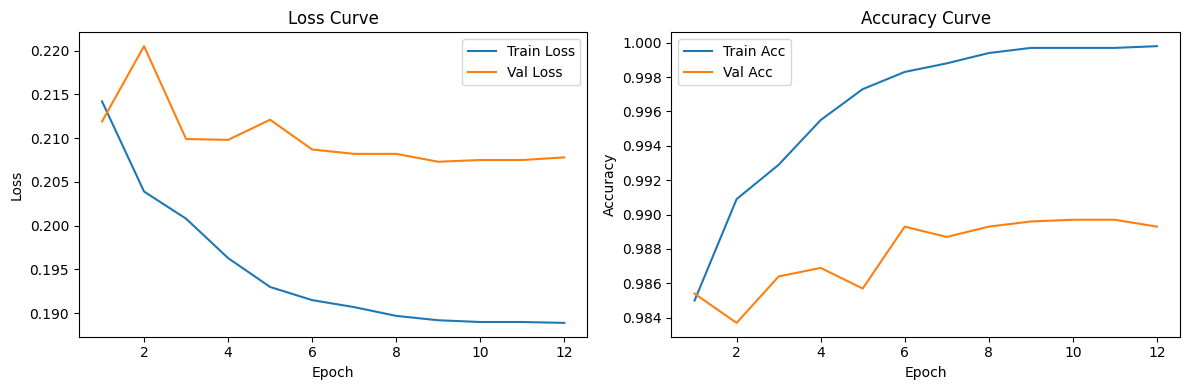

In [ ]:
# ── View training history anytime ────────────────────────────
import json
import pandas as pd

RESULTS_PATH = "/content/drive/MyDrive/training_results.json"

with open(RESULTS_PATH, "r") as f:
    history = json.load(f)

df = pd.DataFrame(history)
print(df.to_string(index=False))

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(df["epoch"], df["train_loss"], label="Train Loss")
plt.plot(df["epoch"], df["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(df["epoch"], df["train_acc"], label="Train Acc")
plt.plot(df["epoch"], df["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

Evaluation

In [ ]:
model.eval()
y_true, y_pred, y_prob = [], [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        probs = tta_predict(model, images)
        threshold = torch.clamp(model.threshold, 0.3, 0.7).item()
        preds = (probs[:, 1] > threshold).long()
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs[:, 1].cpu().numpy())

# Adaptive threshold search
y_true_np = np.array(y_true)
y_prob_np = np.array(y_prob)

best_thresh, best_f1 = 0.5, 0
for t in np.arange(0.2, 0.8, 0.02):
    preds_t = (y_prob_np > t).astype(int)
    f1 = f1_score(y_true_np, preds_t)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f"Best Threshold: {best_thresh:.2f} | Best F1: {best_f1:.4f}")
y_pred_final = (y_prob_np > best_thresh).astype(int)

print(classification_report(y_true_np, y_pred_final, target_names=dataset.classes))
print("Confusion Matrix:\n", confusion_matrix(y_true_np, y_pred_final))
print("ROC-AUC:", roc_auc_score(y_true_np, y_prob_np))

Best Threshold: 0.70 | Best F1: 0.9924
              precision    recall  f1-score   support

  non-tumour       0.99      0.99      0.99      2680
      tumour       0.99      0.99      0.99      3942

    accuracy                           0.99      6622
   macro avg       0.99      0.99      0.99      6622
weighted avg       0.99      0.99      0.99      6622

Confusion Matrix:
 [[2654   26]
 [  34 3908]]
ROC-AUC: 0.9981895128618704


Grad-CAM

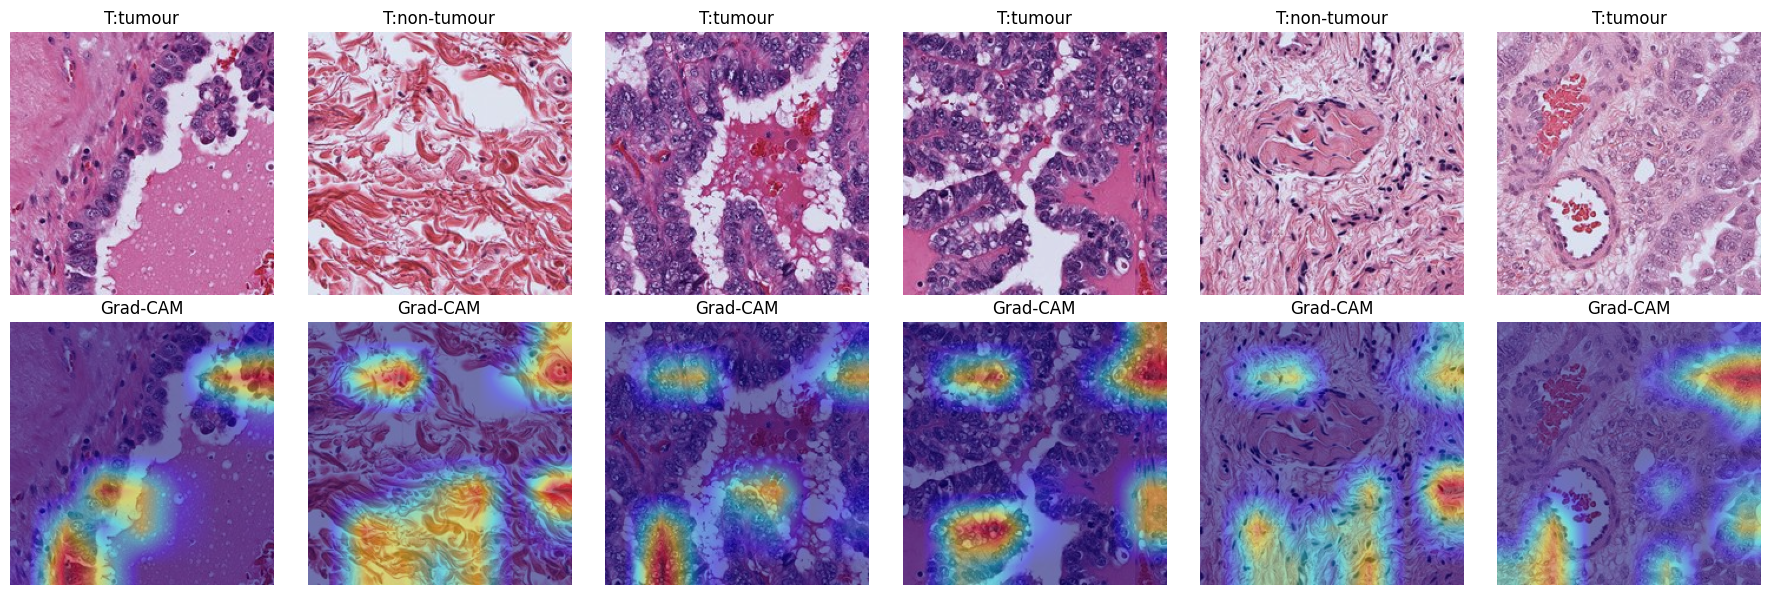

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, _, __, output):
        self.activations = output.detach()

    def _save_gradient(self, _, __, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, x, class_idx=1):
        self.model.zero_grad()
        out = self.model(x)
        out[0, class_idx].backward()
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=x.shape[-2:], mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)


gradcam = GradCAM(model, model.cbam3.sa.conv)

images, labels = next(iter(val_loader))
images = images.to(device)

plt.figure(figsize=(18, 6))
for i in range(6):
    img_tensor = images[i].unsqueeze(0)
    cam = gradcam.generate(img_tensor)

    img_np = images[i].cpu().permute(1, 2, 0).numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = 0.5 * img_np + 0.4 * heatmap

    plt.subplot(2, 6, i + 1)
    plt.imshow(img_np)
    plt.title(f"T:{dataset.classes[labels[i]]}")
    plt.axis("off")

    plt.subplot(2, 6, i + 7)
    plt.imshow(np.clip(overlay, 0, 1))
    plt.title("Grad-CAM")
    plt.axis("off")

plt.tight_layout()
plt.show()